In [1]:
# =============================================================
# IMPORTS & GLOBAL SETTINGS
# =============================================================
# We fix random seeds FIRST so the notebook gives identical
# results every time you run it from top to bottom.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error, r2_score)

# Fix seeds for reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully!")


TensorFlow version: 2.21.0
All libraries loaded successfully!


# Section 1: Data Loading & Exploration

Here we load the raw CSV and take a first look at the data.
We inspect:
- **Shape** – how many rows (readings) and columns (variables) it has
- **Data types** – numbers, text, dates?
- **Missing values** – any gaps in the data?
- **Statistics** – average, min, max of each column


In [2]:
# =============================================================
# SECTION 1 – LOAD THE DATA
# =============================================================

# pd.read_csv reads a comma-separated file into a DataFrame
# (a table-like structure, like a spreadsheet in memory)
df = pd.read_csv('Steel_industry_data.csv')

# --- Shape ---
# shape returns (number_of_rows, number_of_columns)
print("Dataset shape (rows × columns):", df.shape)
print()

# --- Column names and data types ---
# 'object'  = text / string
# 'float64' = decimal number
# 'int64'   = whole number
print("Column names and data types:")
print(df.dtypes)


Dataset shape (rows × columns): (35040, 11)

Column names and data types:
date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
dtype: object


In [3]:
# --- Concise info summary ---
print("\nDataset info:")
df.info()



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtype

In [4]:
# --- Statistical summary of all numeric columns ---
# count = how many values exist
# mean  = average value
# std   = standard deviation (how spread out values are)
# min / max = smallest / largest value
print("\nStatistical summary of numeric columns:")
df.describe()



Statistical summary of numeric columns:


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


In [5]:
# --- Check for missing values ---
# Missing values (NaN) would break our model, so we check carefully.
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())


Missing values per column:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

Total missing values: 0


In [6]:
# --- First 10 rows ---
print("First 10 rows of the dataset:")
df.head(10)


First 10 rows of the dataset:


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load
5,01/01/2018 01:30,3.28,3.56,0.0,0.0,67.76,100.0,5400,Weekday,Monday,Light_Load
6,01/01/2018 01:45,3.60,4.14,0.0,0.0,65.62,100.0,6300,Weekday,Monday,Light_Load
7,01/01/2018 02:00,3.60,4.28,0.0,0.0,64.37,100.0,7200,Weekday,Monday,Light_Load
8,01/01/2018 02:15,3.28,3.64,0.0,0.0,66.94,100.0,8100,Weekday,Monday,Light_Load
9,01/01/2018 02:30,3.78,4.72,0.0,0.0,62.51,100.0,9000,Weekday,Monday,Light_Load


# Section 2: Preprocessing

Raw data cannot go straight into a neural network.
We must:
1. **Drop `date`** – we don't use the raw timestamp as a feature
2. **One-hot encode** categorical text columns (e.g. `Monday` → binary columns)
3. **Scale** numeric features so they all live on the same numeric range
4. **Split** into training (80 %) and test (20 %) sets **without shuffling**
   – this is time-series data, so the order of rows must be preserved


In [7]:
# =============================================================
# SECTION 2 – PREPROCESSING
# =============================================================

# ── Step 1: Drop the 'date' column ──────────────────────────
# We are not using the raw timestamp string as a model input.
df_clean = df.drop(columns=['date'])
print("Columns after dropping 'date':", df_clean.columns.tolist())
print()

# ── Step 2: One-hot encoding ─────────────────────────────────
# A neural network only understands numbers, not words like "Monday".
# One-hot encoding creates one binary (0 or 1) column per category.
# Example: 'Monday' → [1,0,0,0,0,0,0], 'Tuesday' → [0,1,0,0,0,0,0], etc.
categorical_cols = ['WeekStatus', 'Day_of_week', 'Load_Type']
df_enc = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=False)

print("Shape after one-hot encoding:", df_enc.shape)
print("All columns now:")
print(df_enc.columns.tolist())
print()

# ── Step 3: Separate features (X) and target (y) ─────────────
# y = what we want to predict  → 'Usage_kWh'
# X = all other columns        → inputs to the model
target_col = 'Usage_kWh'
X = df_enc.drop(columns=[target_col])
y = df_enc[target_col]
print("Feature matrix X shape:", X.shape)
print("Target vector  y shape:", y.shape)
print()

# ── Step 4: Train / test split (no shuffle!) ─────────────────
# 80 % of rows for training, 20 % for evaluation.
# We must NOT shuffle because time order matters – the model
# should never "see the future" during training.
split_idx = int(len(df_enc) * 0.8)

X_train = X.iloc[:split_idx].values   # first 80 %
X_test  = X.iloc[split_idx:].values   # last  20 %
y_train = y.iloc[:split_idx].values
y_test  = y.iloc[split_idx:].values

print(f"Training set :  X={X_train.shape},  y={y_train.shape}")
print(f"Test     set :  X={X_test.shape},   y={y_test.shape}")
print()

# ── Step 5: Feature scaling ───────────────────────────────────
# StandardScaler shifts each feature to mean=0 and std=1.
# This helps the neural network converge faster and more stably.
#
# IMPORTANT: we fit the scaler ONLY on training data, then apply
# the same transformation to test data.  Fitting on test data too
# would let the model "peek" at future statistics (data leakage).
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform
X_test_sc  = scaler.transform(X_test)         # transform only

print("Scaling done:")
print(f"  X_train mean ≈ {X_train_sc.mean():.4f}  (should be ≈ 0)")
print(f"  X_train std  ≈ {X_train_sc.std():.4f}  (should be ≈ 1)")


Columns after dropping 'date': ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']

Shape after one-hot encoding: (35040, 19)
All columns now:
['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus_Weekday', 'WeekStatus_Weekend', 'Day_of_week_Friday', 'Day_of_week_Monday', 'Day_of_week_Saturday', 'Day_of_week_Sunday', 'Day_of_week_Thursday', 'Day_of_week_Tuesday', 'Day_of_week_Wednesday', 'Load_Type_Light_Load', 'Load_Type_Maximum_Load', 'Load_Type_Medium_Load']

Feature matrix X shape: (35040, 18)
Target vector  y shape: (35040,)

Training set :  X=(28032, 18),  y=(28032,)
Test     set :  X=(7008, 18),   y=(7008,)

Scaling done:
  X_train mean ≈ -0.0000  (should be ≈ 0)
  X_train std  ≈ 

# Section 3: MLP Model (Multilayer Perceptron)

An **MLP** (also called a "fully-connected" or "dense" neural network)
processes each row of data **independently**.  It does not look at
neighbouring rows or any history – every 15-minute reading is treated
in isolation.

Think of each neuron as a small function: it receives numbers, multiplies
each by a learned weight, sums them up, and passes the result through
an *activation function* (ReLU) that squashes negatives to zero.
By stacking many layers of neurons, the network learns complex patterns.

**Architecture chosen:**
```
Input (all features)
  → Dense(128, ReLU) → Dropout(0.2)
  → Dense(64,  ReLU) → Dropout(0.2)
  → Dense(32,  ReLU)
  → Dense(1,   linear)   ← single kWh prediction
```
Dropout randomly deactivates 20 % of neurons each training step to
prevent the model memorising the training set (overfitting).


In [8]:
# =============================================================
# SECTION 3 – MLP MODEL
# =============================================================

num_features = X_train_sc.shape[1]
print(f"Number of input features: {num_features}")

# ── Build the model ──────────────────────────────────────────
# keras.Sequential stacks layers one after another in a straight line.
mlp = keras.Sequential([
    layers.Input(shape=(num_features,)),       # input layer: one row of features
    layers.Dense(128, activation='relu'),       # 128 neurons, ReLU activation
    layers.Dropout(0.2),                        # drop 20 % of neurons randomly
    layers.Dense(64,  activation='relu'),       # 64 neurons
    layers.Dropout(0.2),
    layers.Dense(32,  activation='relu'),       # 32 neurons
    layers.Dense(1)                             # output: a single number (kWh)
], name='MLP')

# ── Compile ─────────────────────────────────────────────────
# optimizer='adam' : an adaptive learning rate algorithm
# loss='mse'       : Mean Squared Error – penalises large errors more
mlp.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Print a table of every layer and its parameter count
mlp.summary()


Number of input features: 18


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ── Early stopping ───────────────────────────────────────────
# If validation loss does not improve for 10 consecutive epochs,
# stop training and restore the best weights seen so far.
early_stop_mlp = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# ── Train ────────────────────────────────────────────────────
# epochs=100    : maximum number of passes through the training data
# batch_size=64 : process 64 samples before updating the weights
# validation_split=0.1 : hold out the last 10 % of training data
#                         to track generalisation during training
print("Training MLP …")
mlp_hist = mlp.fit(
    X_train_sc[:-1], y_train[1:],
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_mlp],
    verbose=1
)
print(f"\nTraining stopped after {len(mlp_hist.history['loss'])} epoch(s).")


Training MLP …
Epoch 1/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 432.6816 - mae: 11.3260 - val_loss: 139.6840 - val_mae: 6.0350
Epoch 2/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 219.0137 - mae: 7.9441 - val_loss: 136.0260 - val_mae: 5.5547
Epoch 3/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 213.5036 - mae: 7.7682 - val_loss: 133.0397 - val_mae: 5.4126
Epoch 4/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 208.7033 - mae: 7.6645 - val_loss: 131.1290 - val_mae: 5.3757
Epoch 5/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 209.6866 - mae: 7.6747 - val_loss: 131.3490 - val_mae: 5.3474
Epoch 6/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 207.3887 - mae: 7.6422 - val_loss: 129.9093 - val_mae: 5.3569
Epoch 7/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 205.0605 - mae: 7.6055 - val_loss: 131.2358 - val_mae: 5.3110
Epoch 8/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 201.9605 - mae: 7.5645 - val_loss: 129.4169 - val_mae: 5.4707


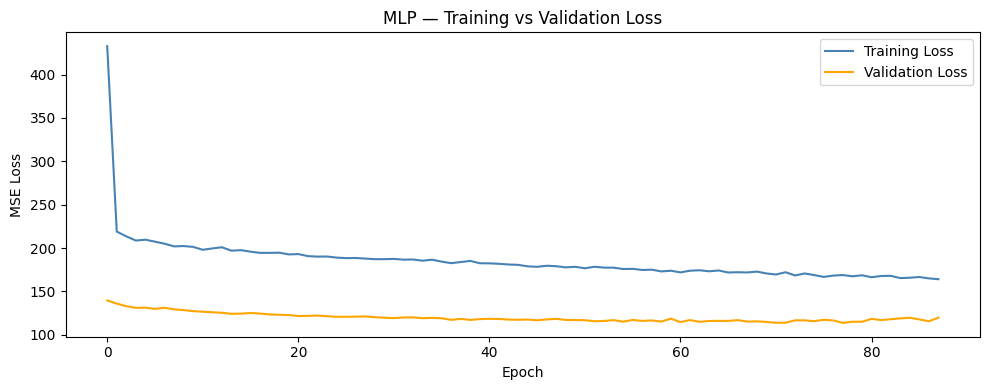

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step
MLP Test Results
  MAE  = 5.2495 kWh
  RMSE = 11.0909 kWh
  R²   = 0.8750


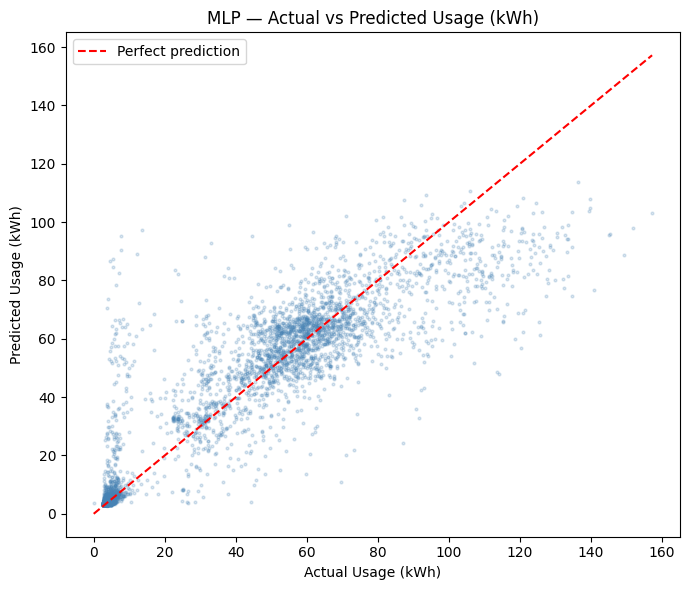

In [10]:
# ── Training / validation loss curve ────────────────────────
# A healthy curve: both lines fall and then level off together.
# If val_loss rises while train_loss falls → the model is overfitting.
plt.figure(figsize=(10, 4))
plt.plot(mlp_hist.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(mlp_hist.history['val_loss'], label='Validation Loss', color='orange')
plt.title('MLP — Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# ── Predict on the test set ──────────────────────────────────
mlp_preds = mlp.predict(X_test_sc[:-1]).flatten()

# ── Evaluation metrics ───────────────────────────────────────
# MAE  : average absolute error in kWh
# RMSE : square-root of average squared error (harsher on big mistakes)
# R²   : 1 = perfect model, 0 = no better than predicting the mean
mlp_mae  = mean_absolute_error(y_test[1:], mlp_preds)
mlp_rmse = np.sqrt(mean_squared_error(y_test[1:], mlp_preds))
mlp_r2   = r2_score(y_test[1:], mlp_preds)

print("MLP Test Results")
print(f"  MAE  = {mlp_mae:.4f} kWh")
print(f"  RMSE = {mlp_rmse:.4f} kWh")
print(f"  R²   = {mlp_r2:.4f}")

# ── Actual vs Predicted scatter plot ────────────────────────
# Points on the red dashed line = perfect prediction.
# Spread around the line shows prediction error.
plt.figure(figsize=(7, 6))
plt.scatter(y_test[1:], mlp_preds, alpha=0.2, s=4, color='steelblue')
lims = [min(y_test[1:].min(), mlp_preds.min()),
        max(y_test[1:].max(), mlp_preds.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
plt.title('MLP — Actual vs Predicted Usage (kWh)')
plt.xlabel('Actual Usage (kWh)')
plt.ylabel('Predicted Usage (kWh)')
plt.legend()
plt.tight_layout()
plt.show()


# Section 4: TCN Model (Temporal Convolutional Network)

Unlike the MLP, a **TCN** looks at a *window* of consecutive past
timesteps before making each prediction.

**Windowing scheme used here:**
- Window size **W = 24** (= 24 × 15 min = 6 hours of history)
- For each position *i*, the model receives rows *i … i+23* as input
  and must predict `Usage_kWh` of row *i+24* (the next 15-min reading)

**Key ideas in TCN architecture:**

| Concept | What it means |
|---|---|
| Causal convolution | Never looks at future timesteps |
| Dilated convolution | Uses gaps between sampled points to "see" further back in time |
| Residual block | Adds the block's *input* to its *output* so gradients can flow |

The 4 residual blocks use dilation rates **[1, 2, 4, 8]**, giving an
effective receptive field of dozens of timesteps without adding depth.


In [11]:
# =============================================================
# SECTION 4 – TCN MODEL
# =============================================================

# ── Step 1: Create sliding-window datasets ───────────────────
# Windowing is applied AFTER the train/test split.
# If we windowed first we could accidentally let test-set rows
# "leak" into training windows (data leakage).
#
# For index i:
#   X_win[i] = X[i : i+W]      ← W consecutive feature rows
#   y_win[i] = y[i + W]         ← the NEXT row's Usage_kWh

WINDOW = 24   # 24 × 15 min = 6 hours

def make_windows(X, y, W):
    """
    X : 2-D array of shape (n_samples, n_features)
    y : 1-D array of shape (n_samples,)
    W : window size (number of past steps)
    Returns arrays of shape (n_windows, W, n_features) and (n_windows,)
    """
    Xw, yw = [], []
    for i in range(len(X) - W):
        Xw.append(X[i : i + W])    # window of W rows
        yw.append(y[i + W])         # target: the very next row
    return np.array(Xw), np.array(yw)

# Apply separately to train and test to prevent leakage
X_tr_tcn, y_tr_tcn = make_windows(X_train_sc, y_train, WINDOW)
X_te_tcn, y_te_tcn = make_windows(X_test_sc,  y_test,  WINDOW)

print("TCN training windows shape:", X_tr_tcn.shape)   # (samples, 24, features)
print("TCN test     windows shape:", X_te_tcn.shape)
print("TCN training targets shape:", y_tr_tcn.shape)


TCN training windows shape: (28008, 24, 18)
TCN test     windows shape: (6984, 24, 18)
TCN training targets shape: (28008,)


In [12]:
# ── Step 2: Build the TCN ────────────────────────────────────
# We use the Keras *Functional API* which allows non-linear
# architectures (e.g. residual connections).

def residual_block(x, filters, kernel_size, dilation, dropout=0.2):
    """
    One TCN residual block.

    Two dilated causal Conv1D layers + BatchNorm + Dropout,
    followed by a skip connection that adds the block input to
    the block output.  If the number of channels differs, a 1×1
    Conv1D is used to project the input to the right shape first.

    Parameters
    ----------
    x           : input tensor  (batch, time, channels)
    filters     : number of convolutional filters (= output channels)
    kernel_size : size of each convolutional filter (we use 3)
    dilation    : dilation rate for both convolutions
    dropout     : fraction of units to randomly drop during training
    """
    # ── First convolution ──────────────────────────────────
    # padding='causal' ensures the convolution never sees future time steps.
    # dilation_rate=d  means the filter skips d-1 positions between taps,
    # allowing it to "see" further back without more parameters.
    h = layers.Conv1D(filters, kernel_size,
                      dilation_rate=dilation,
                      padding='causal',
                      activation='relu')(x)
    h = layers.BatchNormalization()(h)   # stabilises training
    h = layers.Dropout(dropout)(h)

    # ── Second convolution ─────────────────────────────────
    h = layers.Conv1D(filters, kernel_size,
                      dilation_rate=dilation,
                      padding='causal',
                      activation='relu')(h)
    h = layers.BatchNormalization()(h)
    h = layers.Dropout(dropout)(h)

    # ── Skip (residual) connection ────────────────────────
    # Add the original input directly to the block output.
    # This helps gradients flow during backpropagation (avoids
    # the "vanishing gradient" problem in deep networks).
    # If input channels != filters, a 1×1 Conv projects them first.
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, kernel_size=1, padding='same')(x)

    return layers.Add()([x, h])   # skip + block output


n_feat  = X_tr_tcn.shape[2]
inp     = keras.Input(shape=(WINDOW, n_feat), name='tcn_input')

# Stack 4 residual blocks, doubling dilation each time.
# The receptive field grows as: 1→2→4→8 steps apart.
blk = inp
for d in [1, 2, 4, 8]:
    blk = residual_block(blk, filters=64, kernel_size=3, dilation=d)

# Collapse the time dimension by averaging across all 24 timesteps
pool = layers.GlobalAveragePooling1D()(blk)
dense= layers.Dense(64, activation='relu')(pool)
out  = layers.Dense(1, name='output')(dense)   # single kWh prediction

tcn = Model(inputs=inp, outputs=out, name='TCN')
tcn.compile(optimizer='adam', loss='mse', metrics=['mae'])

tcn.summary()


Model: "TCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tcn_input           │ (None, 24, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 64)    │      3,520 │ tcn_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 64)    │      1,216 │ tcn_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 24, 64)    │     12,352 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 24, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 24, 64)    │     12,352 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 24, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 24, 64)    │     12,352 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 24, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 24, 64)    │     12,352 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_6[0][0]  

 Total params: 97,473 (380.75 KB)

 Trainable params: 96,449 (376.75 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [13]:
# ── Train the TCN ────────────────────────────────────────────
early_stop_tcn = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("Training TCN …")
tcn_hist = tcn.fit(
    X_tr_tcn, y_tr_tcn,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_tcn],
    verbose=1
)
print(f"\nTraining stopped after {len(tcn_hist.history['loss'])} epoch(s).")


Training TCN …
Epoch 1/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 434.4428 - mae: 12.5180 - val_loss: 196.2011 - val_mae: 8.5140
Epoch 2/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 207.5613 - mae: 8.3647 - val_loss: 130.8035 - val_mae: 6.2920
Epoch 3/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 177.7520 - mae: 7.5864 - val_loss: 113.3889 - val_mae: 5.7420
Epoch 4/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 160.7352 - mae: 7.1550 - val_loss: 107.9414 - val_mae: 5.5238
Epoch 5/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 152.6990 - mae: 6.9400 - val_loss: 107.5768 - val_mae: 5.4920
Epoch 6/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 146.3522 - mae: 6.7467 - val_loss: 95.3407 - val_mae: 4.9826
Epoch 7/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 140.4869 - mae: 6.5839 - val_loss: 98.9092 - val_mae: 5.1298
Epoch 8/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 137.5600 - mae: 6.4820 - val_loss: 94.1692 - val_mae: 4

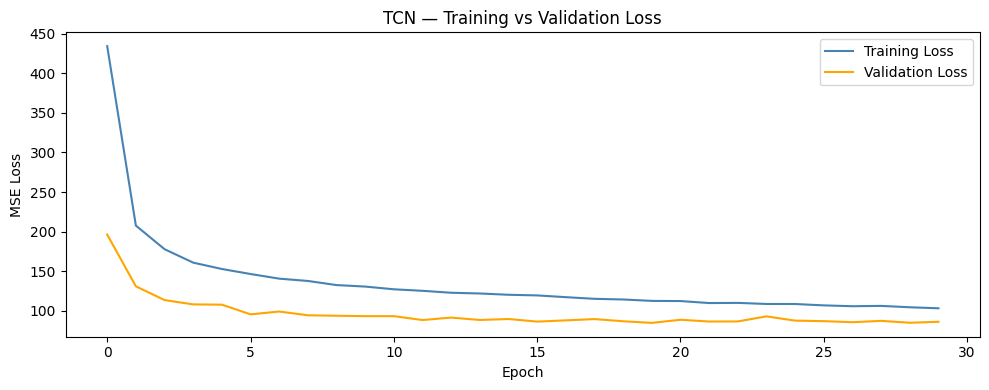

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
TCN Test Results
  MAE  = 5.0042 kWh
  RMSE = 9.5082 kWh
  R²   = 0.9083


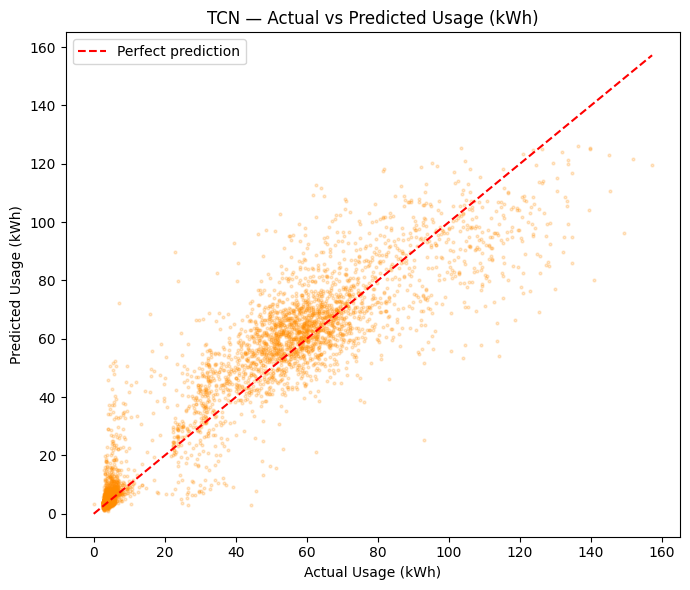

In [14]:
# ── Training / validation loss curve ────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(tcn_hist.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(tcn_hist.history['val_loss'], label='Validation Loss', color='orange')
plt.title('TCN — Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# ── Predict on the test set ──────────────────────────────────
tcn_preds = tcn.predict(X_te_tcn).flatten()

# ── Evaluation metrics ───────────────────────────────────────
tcn_mae  = mean_absolute_error(y_te_tcn, tcn_preds)
tcn_rmse = np.sqrt(mean_squared_error(y_te_tcn, tcn_preds))
tcn_r2   = r2_score(y_te_tcn, tcn_preds)

print("TCN Test Results")
print(f"  MAE  = {tcn_mae:.4f} kWh")
print(f"  RMSE = {tcn_rmse:.4f} kWh")
print(f"  R²   = {tcn_r2:.4f}")

# ── Actual vs Predicted scatter plot ────────────────────────
plt.figure(figsize=(7, 6))
plt.scatter(y_te_tcn, tcn_preds, alpha=0.2, s=4, color='darkorange')
lims = [min(y_te_tcn.min(), tcn_preds.min()),
        max(y_te_tcn.max(), tcn_preds.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
plt.title('TCN — Actual vs Predicted Usage (kWh)')
plt.xlabel('Actual Usage (kWh)')
plt.ylabel('Predicted Usage (kWh)')
plt.legend()
plt.tight_layout()
plt.show()


# Section 5: Model Comparison

We now compare both models side-by-side on the **same test rows**
so the numbers are directly comparable.

> Because TCN windowing removes the first `W=24` rows of the test set,
> we align the MLP by also predicting on `X_test[24:]`.  Both models
> therefore predict the exact same 6,984 target values.

| Metric | Lower is better? |
|--------|-----------------|
| **MAE** | Average absolute error in kWh |
| **RMSE** | Like MAE but punishes large errors more |
| **R²** | Higher is better |


In [15]:
# =============================================================
# SECTION 5 – MODEL COMPARISON
# =============================================================

# ── Align the MLP to the same test slice as the TCN ──────────
# TCN test targets: y_test[WINDOW], y_test[WINDOW+1], …
# MLP must therefore predict on X_test_sc[WINDOW-1:-1] (features at t predict kWh at t+1)
mlp_preds_al = mlp.predict(X_test_sc[WINDOW-1:-1]).flatten()

mlp_mae_al  = mean_absolute_error(y_te_tcn, mlp_preds_al)
mlp_rmse_al = np.sqrt(mean_squared_error(y_te_tcn, mlp_preds_al))
mlp_r2_al   = r2_score(y_te_tcn, mlp_preds_al)

# ── Build a tidy comparison DataFrame ────────────────────────
results = pd.DataFrame({
    'Model': ['MLP', 'TCN'],
    'MAE':   [round(mlp_mae_al,  4), round(tcn_mae,  4)],
    'RMSE':  [round(mlp_rmse_al, 4), round(tcn_rmse, 4)],
    'R²':    [round(mlp_r2_al,   4), round(tcn_r2,   4)],
})

print("=" * 48)
print("         MODEL COMPARISON TABLE")
print("=" * 48)
print(results.to_string(index=False))
print("=" * 48)
print("Lower MAE / RMSE = better  |  Higher R² = better")


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step
         MODEL COMPARISON TABLE
Model    MAE    RMSE     R²
  MLP 5.2594 11.1035 0.8750
  TCN 5.0042  9.5082 0.9083
Lower MAE / RMSE = better  |  Higher R² = better


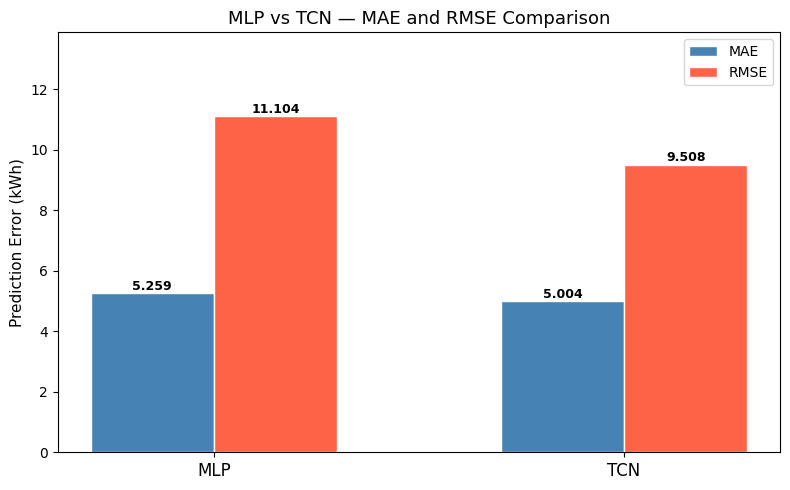

In [16]:
# ── Grouped bar chart: MAE and RMSE side by side ─────────────
fig, ax = plt.subplots(figsize=(8, 5))

x     = np.arange(len(results))   # [0, 1] for MLP and TCN
width = 0.3

bars_mae  = ax.bar(x - width/2, results['MAE'],  width,
                   label='MAE',  color='steelblue',  edgecolor='white')
bars_rmse = ax.bar(x + width/2, results['RMSE'], width,
                   label='RMSE', color='tomato',     edgecolor='white')

# Add numeric labels on top of each bar
for bar in bars_mae:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars_rmse:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], fontsize=12)
ax.set_ylabel('Prediction Error (kWh)', fontsize=11)
ax.set_title('MLP vs TCN — MAE and RMSE Comparison', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, results[['MAE','RMSE']].values.max() * 1.25)
plt.tight_layout()
plt.show()
